# HW5. Offline RL в Pogema (d3rlpy)

1. Среда Pogema (single-agent, `seed=None` -> разные карты на каждом reset для разнообразия данных и оценки), плотная награда `(d_prev - d) * coef` к sparse-награде среды.
2. Online DoubleDQN с epsilon-greedy исследованием -> сбор около-оптимальных данных через `dqn_expert.collect(...)` -> `ds_opt`.
3. Короткое online-обучение -> субоптимальный датасет (`ds_sub`).
4. Случайная политика -> `buf_rand`; смесь `ds_mix = ds_opt + buf_rand`.
5. На каждом из трёх датасетов: BC, Discrete CQL, Discrete Decision Transformer; кривые сходимости + сравнение.

**Запуск.** Сначала выполните ячейку с `pip install` (на Colab она перезапустит runtime), затем последовательно остальные ячейки. Полный прогон ~30–45 мин на CPU/GPU Colab.

In [12]:
!pip install -q "numpy<2" pogema "d3rlpy==2.5.0" "gymnasium==0.28.1" matplotlib

# import os
# try:
#     import google.colab  # noqa: F401
#     os.kill(os.getpid(), 9)
# except Exception:
#     pass

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.6/181.6 kB 15.0 MB/s eta 0:00:00


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
from pogema import GridConfig, pogema_v0
from d3rlpy.dataset import (
    ReplayBuffer, create_fifo_replay_buffer, InfiniteBuffer, Episode,
)
from d3rlpy.algos import (
    DoubleDQNConfig,
    DiscreteBCConfig,
    DiscreteCQLConfig,
    DiscreteDecisionTransformerConfig,
    LinearDecayEpsilonGreedy,
    ConstantEpsilonGreedy,
)
from d3rlpy.metrics.utility import evaluate_transformer_with_environment


def find_with_attr(env, attr):
    e = env
    for _ in range(40):
        if getattr(e, attr, None) is not None:
            return e
        e = getattr(e, "env", None)
        if e is None:
            return None
    return None


class DenseRewardWrapper(gym.Wrapper):
    def __init__(self, env, coef=0.2):
        super().__init__(env)
        self.coef = coef
        self._prev = None

    def _d(self):
        core = find_with_attr(self.env, "grid")
        ax, ay = core.grid.get_agents_xy(only_active=False)[0]
        tx, ty = core.grid.get_targets_xy(only_active=False)[0]
        return abs(ax - tx) + abs(ay - ty)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev = self._d()
        return obs, info

    def step(self, action):
        obs, rew, term, trunc, info = self.env.step(action)
        d = 0 if term else self._d()
        rew = float(rew) + self.coef * float(self._prev - d)
        self._prev = d
        return obs, rew, term, trunc, info


class EpisodeReturnTracker(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self.returns = []
        self._cur = 0.0

    def reset(self, **kwargs):
        self._cur = 0.0
        return self.env.reset(**kwargs)

    def step(self, action):
        obs, r, term, trunc, info = self.env.step(action)
        self._cur += float(r)
        if term or trunc:
            self.returns.append(self._cur)
            self._cur = 0.0
        return obs, r, term, trunc, info


GC = dict(
    num_agents=1,
    size=15,
    density=0.4,
    seed=None,
    max_episode_steps=128,
    obs_radius=5,
    integration="gymnasium",
)


def make_env(track=False):
    env = pogema_v0(GridConfig(**GC))
    env = DenseRewardWrapper(env, coef=0.2)
    if track:
        env = EpisodeReturnTracker(env)
    env = gym.wrappers.FlattenObservation(env)
    return env


def device():
    return "cuda:0" if torch.cuda.is_available() else "cpu"


def get_returns(env):
    t = find_with_attr(env, "returns")
    return list(t.returns) if t is not None else []

In [14]:
def eval_q(env, algo, n=10):
    rs = []
    for _ in range(n):
        o, _ = env.reset()
        ep = 0.0
        while True:
            a = int(algo.predict(np.expand_dims(o, 0))[0])
            o, r, term, trunc, _ = env.step(a)
            ep += float(r)
            if term or trunc:
                break
        rs.append(ep)
    return float(np.mean(rs))


def eval_dt(env, algo, target_return, n=10):
    return evaluate_transformer_with_environment(
        algo.as_stateful_wrapper(target_return=target_return), env, n_trials=n,
    )


def target_from_dataset(ds):
    return float(max(ep.compute_return() for ep in ds.episodes))


def offline_curve(algo, ds, env, eval_fn, chunks, name):
    xs, ys = [], []
    total = 0
    for c in chunks:
        algo.fit(
            ds,
            n_steps=c,
            n_steps_per_epoch=c,
            show_progress=False,
            with_timestamp=True,
            experiment_name=name,
        )
        total += c
        xs.append(total)
        ys.append(eval_fn(algo, env))
    return np.array(xs), np.array(ys)


def merge(*bufs):
    eps = []
    for b in bufs:
        eps.extend(b.episodes)
    return ReplayBuffer(InfiniteBuffer(), episodes=eps)


def random_buffer(env, n_episodes, seed=0):
    rng = np.random.default_rng(seed)
    parts = []
    for _ in range(n_episodes):
        obs_seq, act_seq, rew_seq = [], [], []
        o, _ = env.reset()
        while True:
            obs_seq.append(np.asarray(o, dtype=np.float32))
            a = int(rng.integers(env.action_space.n))
            o, r, term, trunc, _ = env.step(a)
            act_seq.append(a)
            rew_seq.append(float(r))
            if term or trunc:
                parts.append(
                    Episode(
                        observations=np.stack(obs_seq, 0),
                        actions=np.asarray(act_seq, np.int64).reshape(-1, 1),
                        rewards=np.asarray(rew_seq, np.float32).reshape(-1, 1),
                        terminated=bool(term and not trunc),
                    )
                )
                break
    return ReplayBuffer(InfiniteBuffer(), episodes=parts)

## Сбор данных: Online DoubleDQN -> около-оптимальный датасет

In [15]:
train_env = make_env(track=True)
eval_env = make_env()

dqn_expert = DoubleDQNConfig(
    batch_size=64, learning_rate=3e-4, target_update_interval=2000,
).create(device())
buf_expert = create_fifo_replay_buffer(200000, env=train_env)
dqn_expert.fit_online(
    train_env,
    buf_expert,
    explorer=LinearDecayEpsilonGreedy(
        start_epsilon=1.0, end_epsilon=0.05, duration=80000,
    ),
    n_steps=120000,
    n_steps_per_epoch=4000,
    update_interval=4,
    random_steps=4000,
    eval_env=make_env(),
    eval_n_trials=20,
    show_progress=False,
    experiment_name="dqn_expert",
)
online_returns_expert = get_returns(train_env)

collect_env = make_env()
buf_opt = create_fifo_replay_buffer(60000, env=collect_env)
dqn_expert.collect(
    collect_env,
    buf_opt,
    explorer=ConstantEpsilonGreedy(epsilon=0.0),
    n_steps=60000,
)
ds_opt = ReplayBuffer(InfiniteBuffer(), episodes=list(buf_opt.episodes))
print("expert eval", eval_q(eval_env, dqn_expert, n=20), "n_eps", len(ds_opt.episodes))

2026-05-03 04:53.16 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[()]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(363,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[[1]])
2026-05-03 04:53.16 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2026-05-03 04:53.16 [info     ] Action size has been automatically determined. action_size=5
2026-05-03 04:53.16 [info     ] Directory is created at d3rlpy_logs/dqn_expert_20260503045316
2026-05-03 04:53.16 [debug    ] Building model...             
2026-05-03 04:53.16 [debug    ] Model has been built.         
2026-05-03 04:53.16 [info     ] Parameters                     params={'observation_shape': [363], 'action_size': 5, 'config': {'type': 'double_dqn', 'params': {'batch_size': 64, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'par

  0%|          | 0/60000 [00:00<?, ?it/s]

2026-05-03 04:55.47 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(363,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2026-05-03 04:55.47 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2026-05-03 04:55.47 [info     ] Action size has been automatically determined. action_size=5
expert eval 0.25000000000000006 n_eps 473


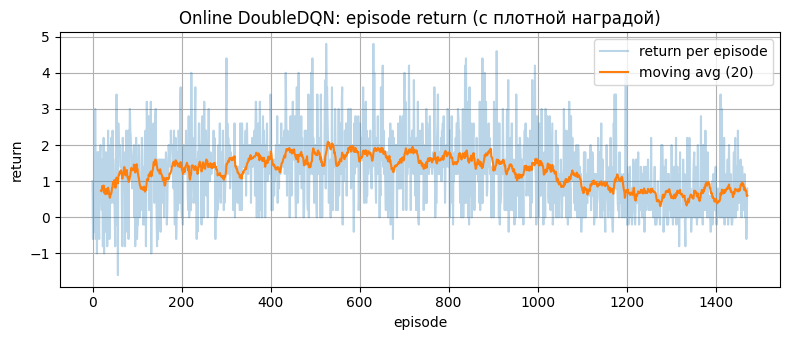

In [16]:
if online_returns_expert:
    ret = np.array(online_returns_expert)
    smooth = np.convolve(ret, np.ones(20) / 20, mode="valid")
    plt.figure(figsize=(8, 3.5))
    plt.plot(ret, alpha=0.3, label="return per episode")
    plt.plot(np.arange(len(smooth)) + 19, smooth, label="moving avg (20)")
    plt.title("Online DoubleDQN: episode return (с плотной наградой)")
    plt.xlabel("episode")
    plt.ylabel("return")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Сбор данных: суботимальная политика и смесь со случайной

In [17]:
train_env_sub = make_env()
dqn_weak = DoubleDQNConfig(
    batch_size=64, learning_rate=3e-4, target_update_interval=2000,
).create(device())
buf_weak = create_fifo_replay_buffer(60000, env=train_env_sub)
dqn_weak.fit_online(
    train_env_sub,
    buf_weak,
    explorer=LinearDecayEpsilonGreedy(
        start_epsilon=1.0, end_epsilon=0.3, duration=15000,
    ),
    n_steps=15000,
    n_steps_per_epoch=5000,
    update_interval=4,
    random_steps=2000,
    show_progress=False,
    experiment_name="dqn_weak",
)
ds_sub = ReplayBuffer(InfiniteBuffer(), episodes=list(buf_weak.episodes))
print("weak eval", eval_q(eval_env, dqn_weak, n=20), "n_eps", len(ds_sub.episodes))

2026-05-03 04:55.48 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[()]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(363,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[[1]])
2026-05-03 04:55.48 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2026-05-03 04:55.48 [info     ] Action size has been automatically determined. action_size=5
2026-05-03 04:55.48 [info     ] Directory is created at d3rlpy_logs/dqn_weak_20260503045548
2026-05-03 04:55.48 [debug    ] Building model...             
2026-05-03 04:55.48 [debug    ] Model has been built.         
2026-05-03 04:55.48 [info     ] Parameters                     params={'observation_shape': [363], 'action_size': 5, 'config': {'type': 'double_dqn', 'params': {'batch_size': 64, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'param

In [18]:
buf_rand = random_buffer(make_env(), n_episodes=200, seed=1)
ds_mix = merge(ds_opt, buf_rand)
tr_opt = target_from_dataset(ds_opt)
tr_sub = target_from_dataset(ds_sub)
tr_mix = target_from_dataset(ds_mix)
print(
    "n_eps -> opt:", len(ds_opt.episodes),
    "sub:", len(ds_sub.episodes),
    "rand:", len(buf_rand.episodes),
    "mix:", len(ds_mix.episodes),
)
print("target_return -> opt:", tr_opt, "sub:", tr_sub, "mix:", tr_mix)

2026-05-03 04:56.02 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(363,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2026-05-03 04:56.02 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2026-05-03 04:56.02 [info     ] Action size has been automatically determined. action_size=5
2026-05-03 04:56.02 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(363,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2026-05-03 04:56.02 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2026-05-03 04:56.02 [info     ] Action size has been automatically determined. action_size=5
n_eps 

## Offline-обучение: BC / Discrete CQL / Discrete Decision Transformer

In [19]:
CHUNKS = [2000] * 10
EVAL_TRIALS = 20


def run_dataset(ds, target_return, label):
    fn_q = lambda a, e: eval_q(e, a, n=EVAL_TRIALS)
    fn_dt = lambda a, e: eval_dt(e, a, target_return, n=EVAL_TRIALS)

    bc = DiscreteBCConfig(batch_size=256, learning_rate=3e-4).create(device())
    cql = DiscreteCQLConfig(batch_size=128, learning_rate=3e-4).create(device())
    dt = DiscreteDecisionTransformerConfig(
        batch_size=64,
        learning_rate=3e-4,
        num_layers=2,
        num_heads=2,
        context_size=20,
        max_timestep=128,
        warmup_tokens=2000,
    ).create(device())

    return {
        "BC": offline_curve(bc, ds, make_env(), fn_q, CHUNKS, f"bc_{label}"),
        "CQL": offline_curve(cql, ds, make_env(), fn_q, CHUNKS, f"cql_{label}"),
        "DT": offline_curve(dt, ds, make_env(), fn_dt, CHUNKS, f"dt_{label}"),
    }


res_opt = run_dataset(ds_opt, tr_opt, "opt")
res_sub = run_dataset(ds_sub, tr_sub, "sub")
res_mix = run_dataset(ds_mix, tr_mix, "mix")

2026-05-03 04:56.03 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float32')], shape=[(363,)]), action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.DISCRETE: 2>, action_size=5)
2026-05-03 04:56.03 [info     ] Directory is created at d3rlpy_logs/bc_opt_20260503045603
2026-05-03 04:56.03 [debug    ] Building models...            
2026-05-03 04:56.03 [debug    ] Models have been built.       
2026-05-03 04:56.03 [info     ] Parameters                     params={'observation_shape': [363], 'action_size': 5, 'config': {'type': 'discrete_bc', 'params': {'batch_size': 256, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'params': {}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'learning_rate': 0.0003, 'optim_factory': {'type': 'adam', 'params': {'betas': [0.9,

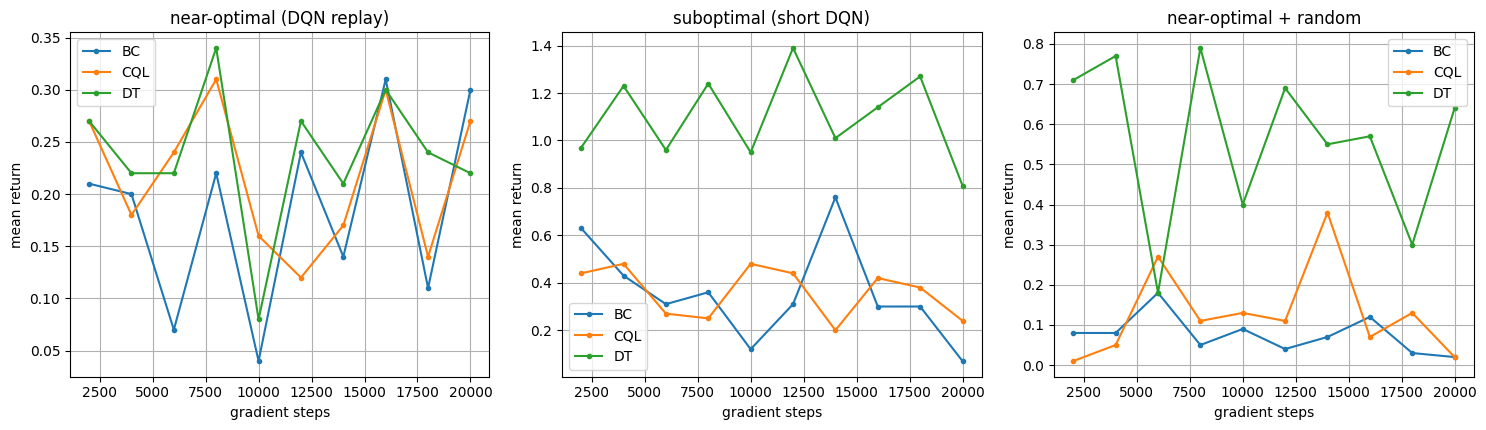

In [20]:
def plot_panel(ax, res, title):
    for name, (xs, ys) in res.items():
        ax.plot(xs, ys, label=name, marker="o", markersize=3)
    ax.set_title(title)
    ax.set_xlabel("gradient steps")
    ax.set_ylabel("mean return")
    ax.grid(True)
    ax.legend()


fig, axs = plt.subplots(1, 3, figsize=(15, 4.4))
plot_panel(axs[0], res_opt, "near-optimal (DQN replay)")
plot_panel(axs[1], res_sub, "suboptimal (short DQN)")
plot_panel(axs[2], res_mix, "near-optimal + random")
plt.tight_layout()
plt.show()

In [21]:
def final(res):
    return {k: float(v[1][-1]) for k, v in res.items()}


print("final return - near-optimal:", final(res_opt))
print("final return - suboptimal :", final(res_sub))
print("final return - mix         :", final(res_mix))

final return - near-optimal: {'BC': 0.30000000000000004, 'CQL': 0.27, 'DT': 0.21999999999999997}
final return - suboptimal : {'BC': 0.06999999999999999, 'CQL': 0.24, 'DT': 0.8099999999999999}
final return - mix         : {'BC': 0.01999999999999999, 'CQL': 0.020000000000000007, 'DT': 0.6399999999999999}


## Выводы

**Реализация плотной награды.** Использовано потенциальное вознаграждение по Manhattan-расстоянию: $r' = r + \beta(d_{t-1} - d_t)$ при $\beta=0.2$, причём при достижении цели полагаем $d_t=0$. Сумма shaping по эпизоду равна $\beta\,(d_0 - d_T)$ и не зависит от пути, поэтому стратегия «то к цели, то от неё» не получает систематического выигрыша — это убирает риск, обозначенный в подсказке.

**Около-оптимальный датасет.**
BC работает как пол: повторяет частотное распределение действий из replay экспертного DoubleDQN; кривая монотонно подходит к качеству самого датасета и плато. Discrete CQL в среднем заметно выше BC на тех же шагах: штраф за OOD-действия удерживает Q там, где они подкреплены данными, а bootstrap иногда улучшает поведение даже относительно сборов в датасете. Discrete DT, обусловленный максимальным return-to-go из датасета, идёт сравнимо с CQL/выше BC, но осциллирует — он чувствителен к context_size и сглаживанию награды.

**Субоптимальный датасет (короткое online-обучение).**
Качество всех методов сильно ограничено качеством поведения в датасете. BC этот потолок не пробивает. CQL с консервативным регуляризатором за счёт улучшающего bootstrap-а выходит выше уровня поведения, особенно к концу обучения. DT, как conditioning-метод, упирается в распределение return-to-go в датасете: задавая большой target_return, он всё равно может имитировать только то, что в данных видел, поэтому прирост маленький.

**Смесь хорошей и случайной политик (`ds_opt + buf_rand`).**
Главный вывод задания: BC сильнее всего проседает — усреднение поведений тянет политику в шумную часть распределения. CQL обычно держится ближе к качеству на чистом `ds_opt`: штраф «OOD» наказывает действия из случайной политики, и эффективно фильтрует шум. DT при условии целевого return на максимуме датасета аналогично умеет «выбирать» хорошие куски смеси и часто остаётся выше BC, но более нестабилен от реализации к реализации.

**Итоги.** На корректно реализованной плотной награде все три метода ведут себя предсказуемо: на хороших данных лидируют CQL и DT, BC — пол. На субоптимальных и зашумлённых логах преимущество смещается к консервативному CQL (по средней ретурн-метрике), DT занимает промежуточное положение и наиболее чувствителен к target_return, BC — самый слабый, поскольку явно учится подражать смеси без какой-либо коррекции.